# Introduction

Explain here all details

- **Today Yield (kWh)** - Energy generated by the inverter during that specific day.
- **Today Full Load Hours (h)** - Number of hours the inverter operated at full power on that day. This helps measure system efficiency.
- **Energy to Grid (kWh)** - Energy exported from the inverter to the public electricity grid that day.
- **Energy from Grid (kWh)** - Energy imported from the grid to power local loads or charge batteries.
- **Energy to Battery (kWh)** - Energy sent to the battery for storage (charged energy).
- **Energy from Battery (kWh)**- Energy discharged from the battery to support local loads.
- **Load Consumption (kWh)**- Total energy consumed by your connected loads (home, business, etc.) that day — including both grid and battery sources.
- **Generation (kWh)** - Total energy generated by the inverter on that day. In most cases, it’s the same as “Today Yield” unless there’s a specific calculation adjustment.

## Import Statements

In [2]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
from openpyxl import load_workbook
from openpyxl.drawing.image import Image
from openpyxl.styles import Alignment

Matplotlib is building the font cache; this may take a moment.


## Notebook Presentation

In [3]:
pd.options.display.float_format = '{:,.2f}'.format
plt.style.available
plt.style.use("seaborn-v0_8")
month_report = "November"
file_name=f"Inverter Monthly Report_{month_report}.xls"

## Load the Data

In [5]:
data = pd.read_excel(file_name, header=6,index_col="Time", parse_dates=["Time"], date_format="%Y-%m-%d").drop(columns=["Inverter SN","Number"])


# Preliminary Data Exploration

* What is the shape of the DataFrames?
* How many rows and columns do they have?
* What are the column names?
* Are there any NaN values or duplicates?

In [4]:
#SHAPE OF DATAFRAMES
shape_data = data.shape

print(f"** Dataframe has {shape_data[0]} rows and {shape_data[1]} columns")
print(f"** List of columns {data.columns.values}")
#Descriptip information, info, describe, head, nunique values, ...
data.head()


** Dataframe has 10 rows and 8 columns
** List of columns ['Today Yield(kWh)' 'Today Full Load Hours(h)' 'Energy to Grid(kWh)'
 'Energy from Grid(kWh)' 'Energy to Battery(kWh)'
 'Energy from Battery(kWh)' 'Load Consumption(kWh)' 'Generation(kWh)']


,Today Yield(kWh),Today Full Load Hours(h),Energy to Grid(kWh),Energy from Grid(kWh),Energy to Battery(kWh),Energy from Battery(kWh),Load Consumption(kWh),Generation(kWh)
Time,,,,,,,,
01/11/2025,9.00,1.80,4.08,6.72,6,5,10,9.00
02/11/2025,8.00,1.60,3.96,6.60,6,6,11,8.00
03/11/2025,6.00,1.20,0.00,36.84,7,7,43,6.00
04/11/2025,6.00,1.20,1.20,7.68,7,6,11,6.00
05/11/2025,2.50,0.50,0.00,8.52,5,6,11,2.50


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10 entries, 01/11/2025 to 10/11/2025
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Today Yield(kWh)          10 non-null     float64
 1   Today Full Load Hours(h)  10 non-null     float64
 2   Energy to Grid(kWh)       10 non-null     float64
 3   Energy from Grid(kWh)     10 non-null     float64
 4   Energy to Battery(kWh)    10 non-null     int64  
 5   Energy from Battery(kWh)  10 non-null     int64  
 6   Load Consumption(kWh)     10 non-null     int64  
 7   Generation(kWh)           10 non-null     float64
dtypes: float64(5), int64(3)
memory usage: 720.0+ bytes


In [6]:
data.describe()

,Today Yield(kWh),Today Full Load Hours(h),Energy to Grid(kWh),Energy from Grid(kWh),Energy to Battery(kWh),Energy from Battery(kWh),Load Consumption(kWh),Generation(kWh)
count,10.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00
mean,5.32,1.06,1.58,17.88,6.10,5.50,21.00,5.32
std,2.87,0.57,1.77,14.06,1.66,1.43,14.72,2.87
min,0.00,0.00,0.00,6.60,4.00,3.00,6.00,0.00
25%,3.38,0.68,0.00,7.02,5.00,5.00,11.00,3.38
50%,6.10,1.22,0.90,8.10,6.00,5.50,11.00,6.10
75%,6.88,1.38,3.36,30.96,6.75,6.00,35.00,6.88
max,9.00,1.80,4.08,39.24,10.00,8.00,43.00,9.00


In [7]:
#UNIQUE VALUES PER COLUMN
#data.nunique()

## 1. Data Cleaning - Check for Missing Values and Duplicates

Consider how to deal with the NaN values.

In [8]:
#NAN values - there is only one row with NAN values
print(f"* Does data has empty values: {data.isna().values.any()}")
print(f"\n* Data has empty values in the following columns:\n{data.isna().sum()}")
print(f"\n* Total empty values in data: {data.isna().sum().sum()}")

* Does data has empty values: False

* Data has empty values in the following columns:
Today Yield(kWh)            0
Today Full Load Hours(h)    0
Energy to Grid(kWh)         0
Energy from Grid(kWh)       0
Energy to Battery(kWh)      0
Energy from Battery(kWh)    0
Load Consumption(kWh)       0
Generation(kWh)             0
dtype: int64

* Total empty values in data: 0


## 2. Data Cleaning - Check for Duplicates

In [9]:
#DUPLICATE VALUES

print(f"Does data has duplicate values: {data.duplicated().values.any()}")
print(f"Total Duplicated: {data.duplicated().value_counts()}")

Does data has duplicate values: False
Total Duplicated: False    10
Name: count, dtype: int64


## 3. Data Cleaning - Convert Data Types
check for datetimes, int, floating, category ... using astype or pd.to_dateformat

In [10]:
#there are 2 columns that coulc be converted into categories - > Undergraduate Major and Group
data.dtypes

Today Yield(kWh)            float64
Today Full Load Hours(h)    float64
Energy to Grid(kWh)         float64
Energy from Grid(kWh)       float64
Energy to Battery(kWh)        int64
Energy from Battery(kWh)      int64
Load Consumption(kWh)         int64
Generation(kWh)             float64
dtype: object

# Data Analysis

### Calculate key indicators

In [11]:
#Today Yield (kWh) - Energy generated by the inverter during that specific day.
#Today Full Load Hours (h) - Number of hours the inverter operated at full power on that day. This helps measure system efficiency.
#Energy to Grid (kWh) - Energy exported from the inverter to the public electricity grid that day.
#Energy from Grid (kWh) - Energy imported from the grid to power local loads or charge batteries.
#Energy to Battery (kWh) - Energy sent to the battery for storage (charged energy).
#Energy from Battery (kWh)- Energy discharged from the battery to support local loads.
#Load Consumption (kWh)- Total energy consumed by your connected loads (home, business, etc.) that day — including both grid and battery sources.
#Generation (kWh) - Total energy generated by the inverter on that day. In most cases, it’s the same as “Today Yield” unless there’s a specific calculation adjustment.

In [12]:


# --- Energy totals ---
total_yield = data["Today Yield(kWh)"].sum()
total_full_load_hours = data["Today Full Load Hours(h)"].sum()
total_energy_to_grid = data["Energy to Grid(kWh)"].sum()
total_energy_from_grid = data["Energy from Grid(kWh)"].sum()
total_energy_to_battery = data["Energy to Battery(kWh)"].sum()
total_energy_from_battery = data["Energy from Battery(kWh)"].sum()
total_load_consumption = data["Load Consumption(kWh)"].sum()
total_generation = data["Generation(kWh)"].sum()
avg_generation = data["Generation(kWh)"].mean()

# --- Derived metrics ---
#data["Net_to_Grid_kWh"] = data["Energy to Grid(kWh)"] - data["Energy from Grid(kWh)"]
data["Battery_Efficiency_%"] = data["Energy from Battery(kWh)"] / data["Energy to Battery(kWh)"]
data["From_Solar_kWh"] = data["Load Consumption(kWh)"] - data["Energy from Grid(kWh)"]
avg_from_solar = data["From_Solar_kWh"].mean()
total_energy_from_solar = data["From_Solar_kWh"].sum()
data["Solar_%"] = data["From_Solar_kWh"] / data["Load Consumption(kWh)"] * 100
data["Grid_%"] = data["Energy from Grid(kWh)"] / data["Load Consumption(kWh)"] * 100

# --- Financial + CO₂ ---
#how much is paying the goverment now 0.185€ per KWh
current_selling_rate = 0.185 # €/kWh exported

#rates at night (2-6) is 8.9 cents and during day 6-1:59 is 37.93 cents
night_rate = 0.089 # €/kWh imported night
day_rate = 0.3793 # €/kWh imported day

co2_factor = 0.45      # kg CO₂ avoided per kWh generated
#the cost we do not know since we need to calculate base on day rate or night rate so we need daily stats.
#df["Cost_Saved_€"] = df["Energy_from_Grid_kWh"] * grid_price
data["Revenue_€"] = data["Energy to Grid(kWh)"] * current_selling_rate
total_revenue_sent_to_grid = data["Revenue_€"].sum()
data["CO2_Saved_kg"] = data["Generation(kWh)"] * co2_factor

In [13]:
data.sum()

Today Yield(kWh)            53.20
Today Full Load Hours(h)    10.64
Energy to Grid(kWh)         15.84
Energy from Grid(kWh)      178.80
Energy to Battery(kWh)      61.00
Energy from Battery(kWh)    55.00
Load Consumption(kWh)      210.00
Generation(kWh)             53.20
Battery_Efficiency_%         9.12
From_Solar_kWh              31.20
Solar_%                    183.26
Grid_%                     816.74
Revenue_€                    2.93
CO2_Saved_kg                23.94
dtype: float64

In [14]:
#data[["Energy to Grid(kWh)", "Revenue_€"]]


### 1 - Energy Production Analysis
✅ Insights: Identify days with low generation (potential shading, inverter fault, or bad weather).

In [15]:
#daily treNd
plt.figure(figsize=(20,6))
plt.plot(data.index, data["Generation(kWh)"], marker="o")

# ✅ Add horizontal line for average
plt.axhline(y=avg_generation, color='red', linestyle='--', linewidth=0.5, label=f'Average: {avg_generation:.2f} kWh')

plt.title("Daily Energy Generation (kWh)")
plt.xlabel("Date")
plt.ylabel("Generation (kWh)")
plt.grid(True)
# ✅ Rotate date labels for better readability
plt.xticks(rotation=90)  # or 30, 60, 90 depending on how dense the data is

#save chart to be used in excel
chart_path4 = f"{month_report}/daily_energy_generation.png"

plt.tight_layout()  # 🔥 ensures nothing is cut off, auto-format date labels for better spacing
plt.savefig(chart_path4, bbox_inches="tight")
plt.close()
plt.show()

### 2 - Grid Interaction Analysis
✅ Goal: See how much power goes to and from the electricity grid.

#### Grid Export / Import Report

In [16]:
table_grid_interaction = data[["Load Consumption(kWh)","Energy from Grid(kWh)","From_Solar_kWh","Energy to Grid(kWh)", "Revenue_€"]]
table_grid_interaction

,Load Consumption(kWh),Energy from Grid(kWh),From_Solar_kWh,Energy to Grid(kWh),Revenue_€
Time,,,,,
01/11/2025,10,6.72,3.28,4.08,0.75
02/11/2025,11,6.60,4.40,3.96,0.73
03/11/2025,43,36.84,6.16,0.00,0.00
04/11/2025,11,7.68,3.32,1.20,0.22
05/11/2025,11,8.52,2.48,0.00,0.00
06/11/2025,11,7.20,3.80,2.28,0.42
07/11/2025,41,39.24,1.76,0.00,0.00
08/11/2025,37,32.40,4.60,0.60,0.11
09/11/2025,29,26.64,2.36,3.72,0.69


In [17]:
fig1 = data.plot(y=["Energy from Grid(kWh)", "Energy to Grid(kWh)"], kind="bar",width=0.8, xlabel="", ylabel="kWh", title="Grid Export vs Import", figsize=(20,6) )
for container in fig1.containers:
    fig1.bar_label(container, fmt="%g", label_type="center", padding=3, fontsize=8, color="white")

#save chart to be used in excel
chart_path1 = f"{month_report}/grid_export_vs_import.png"
plt.tight_layout()  # 🔥 ensures nothing is cut off
plt.savefig(chart_path1, bbox_inches="tight")
plt.close()

In [18]:

ax = data["From_Solar_kWh"].plot(kind="bar", figsize=(20,6), width=0.8, ylabel="kWh", title="Energy From Solar vs Revenue €", color="green")
data["Revenue_€"].plot(ax=ax, secondary_y=True, color="darkorange", marker="o", ylabel="Total €")

for container in ax.containers:
    ax.bar_label(container, fmt="%g", label_type="center", padding=3, fontsize=8, color="white")

#save chart to be used in excel
chart_path2 = f"{month_report}/energy_from_solar_revenue.png"

plt.tight_layout()  # 🔥 ensures nothing is cut off
plt.savefig(chart_path2, bbox_inches="tight")
plt.close()


#### Revenue Report

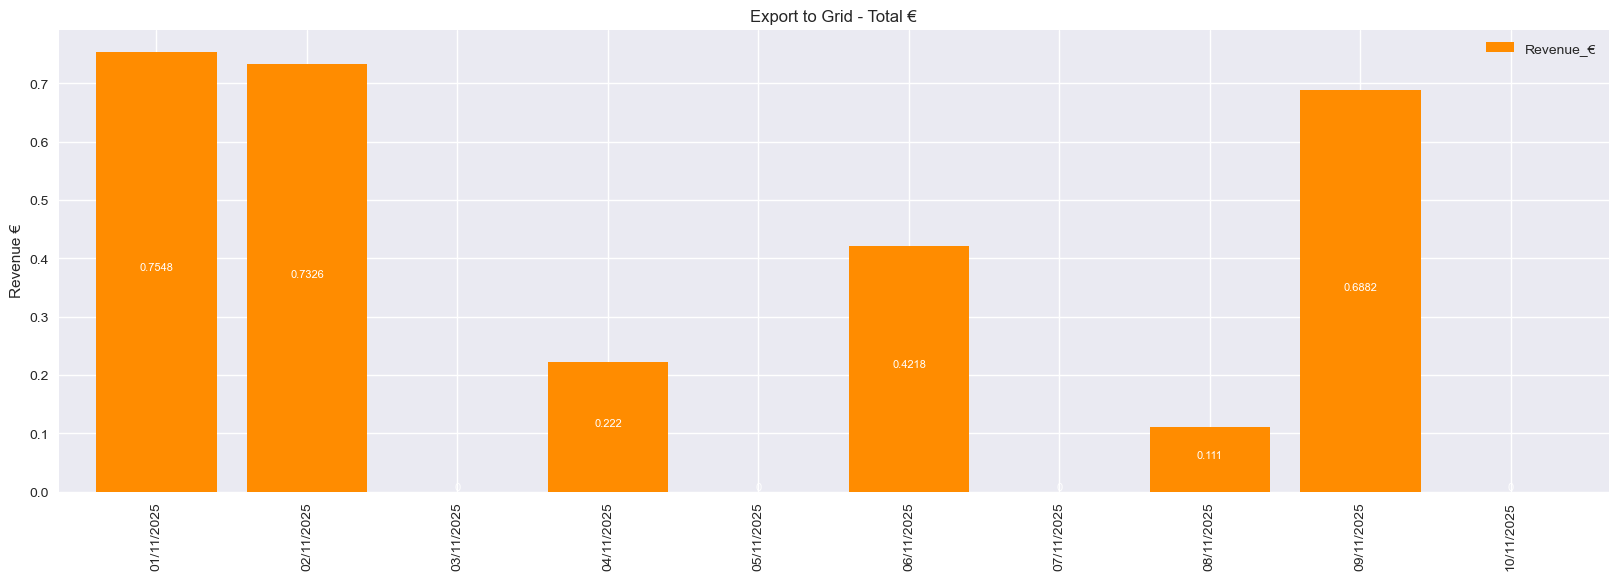

In [26]:
fig_revenue = data.plot(y=["Revenue_€"], kind="bar", width=0.8, xlabel="", ylabel="Revenue €", title="Export to Grid - Total €", figsize=(20,6), color="darkorange" )
for container in fig_revenue.containers:
    fig_revenue.bar_label(container, fmt="%g", label_type="center", padding=3, fontsize=8, color="white")

#### Self-Consumption Ratio


In [19]:
#How much of the produced energy you consume directly.
table_self_consumption = data[["Load Consumption(kWh)","Energy from Grid(kWh)","From_Solar_kWh","Solar_%"]]
table_self_consumption

,Load Consumption(kWh),Energy from Grid(kWh),From_Solar_kWh,Solar_%
Time,,,,
01/11/2025,10,6.72,3.28,32.80
02/11/2025,11,6.60,4.40,40.00
03/11/2025,43,36.84,6.16,14.33
04/11/2025,11,7.68,3.32,30.18
05/11/2025,11,8.52,2.48,22.55
06/11/2025,11,7.20,3.80,34.55
07/11/2025,41,39.24,1.76,4.29
08/11/2025,37,32.40,4.60,12.43
09/11/2025,29,26.64,2.36,8.14


In [20]:
fig3 = data.plot(y=["Solar_%"], kind="bar", width=0.8, xlabel="", ylabel="Self Consumption Ratio%", title="How much of the produced energy you consume directly", figsize=(20,6))
for container in fig3.containers:
    fig3.bar_label(container, fmt="%d", label_type="center", padding=3, fontsize=8, color="white")

#save chart to be used in excel
chart_path3 = f"{month_report}/energy_consumed_directly.png"

plt.tight_layout()  # 🔥 ensures nothing is cut off
plt.savefig(chart_path3, bbox_inches="tight")
plt.close()

### 3 - Load Consumption Analysis
Goal: Evaluate how energy is consumed in the household or facility.


#### Daily Load Profile
How total consumption changes daily.


In [21]:
fig_daily_load_consumption = data.plot(y=["Load Consumption(kWh)", "Generation(kWh)"], kind="line", xlabel="", ylabel="kWh", title="Load Consumption vs Generation", figsize=(20,6), marker="o", linewidth=2, ylim=0)
plt.grid(linestyle="--")
# Show all x-axis labels
plt.xticks(ticks=range(len(data.index)), labels=data.index, rotation=90)

#save chart to be used in excel
chart_path5 = f"{month_report}/load_consumption_vs_generation.png"

plt.tight_layout()  # 🔥 ensures nothing is cut off
plt.savefig(chart_path5, bbox_inches="tight")
plt.close()

In [38]:
fig_daily_load_consumption_bars = data.plot(y=["Load Consumption(kWh)"], kind="bar", xlabel="", ylabel="kWh", title="Total Consumed", figsize=(20,6), ylim=0)
for container in fig_daily_load_consumption_bars.containers:
    fig_daily_load_consumption_bars.bar_label(container, fmt="%d", label_type="center", padding=3, fontsize=8, color="white")

#save chart to be used in excel
chart_consumed= f"{month_report}/energy_consumed.png"

plt.tight_layout()  # 🔥 ensures nothing is cut off
plt.savefig(chart_consumed, bbox_inches="tight")
plt.close()

In [39]:
fig_daily_generation_bars = data.plot(y=["Generation(kWh)"], kind="bar", xlabel="", ylabel="kWh", title="Total Generated", figsize=(20,6), ylim=0, color="green")
for container in fig_daily_generation_bars.containers:
    fig_daily_generation_bars.bar_label(container, fmt="%d", label_type="center", padding=3, fontsize=8, color="white")

#save chart to be used in excel
chart_generated= f"{month_report}/energy_generated.png"

plt.tight_layout()  # 🔥 ensures nothing is cut off
plt.savefig(chart_generated, bbox_inches="tight")
plt.close()

In [37]:
table_consumed_vs_generated = data[["Load Consumption(kWh)","Generation(kWh)"]]
table_consumed_vs_generated

,Load Consumption(kWh),Generation(kWh)
Time,,
01/11/2025,10,9.00
02/11/2025,11,8.00
03/11/2025,43,6.00
04/11/2025,11,6.00
05/11/2025,11,2.50
06/11/2025,11,6.50
07/11/2025,41,2.00
08/11/2025,37,7.00
09/11/2025,29,6.20


#### Source Breakdown
How total consumption changes daily. 
Where the load’s energy comes from.
% from solar, % from battery, % from grid.

Your inverter report includes:
- Energy_from_Grid_kWh: energy imported from the grid
- Energy_from_Battery_kWh: energy discharged from the battery
- Load_Consumption_kWh: total energy consumed by your home or site

That means part of your load comes from:
1. Solar directly (energy generated and used instantly, without going to battery or grid)
2. Battery (energy stored earlier and later discharged)
3. Grid (energy imported)

In [22]:
table_source_breakdown = data[["Load Consumption(kWh)","From_Solar_kWh","Solar_%","Energy from Grid(kWh)","Grid_%"]]
table_source_breakdown

,Load Consumption(kWh),From_Solar_kWh,Solar_%,Energy from Grid(kWh),Grid_%
Time,,,,,
01/11/2025,10,3.28,32.80,6.72,67.20
02/11/2025,11,4.40,40.00,6.60,60.00
03/11/2025,43,6.16,14.33,36.84,85.67
04/11/2025,11,3.32,30.18,7.68,69.82
05/11/2025,11,2.48,22.55,8.52,77.45
06/11/2025,11,3.80,34.55,7.20,65.45
07/11/2025,41,1.76,4.29,39.24,95.71
08/11/2025,37,4.60,12.43,32.40,87.57
09/11/2025,29,2.36,8.14,26.64,91.86


In [23]:
# Select percentage columns
percentages = table_source_breakdown[["Solar_%", "Grid_%"]]

# Create stacked bar chart
ax = percentages.plot(
    kind="bar",
    stacked=True,
    color=["#f9d71c", "#5dade2"],  # Solar yellow, Grid blue
    figsize=(10, 6),
    edgecolor="black",
    width=0.8,
)

# Formatting
plt.title("Energy Source Breakdown - Solar% vs Grid%", fontsize=14)
plt.ylabel("Percentage (%)", fontsize=12)
plt.xlabel("Date", fontsize=12)
plt.xticks(rotation=90, ha='right')
plt.ylim(0, 100)
plt.legend(title="Source")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Annotate bars with % values inside
for i, (idx, row) in enumerate(percentages.iterrows()):
    solar = row["Solar_%"]
    grid = row["Grid_%"]
    # Solar label
    if solar > 3:  # Avoid clutter if value too small
        ax.text(
            i, solar / 2, f"{solar:.1f}%", ha="center", va="center", color="black", fontsize=9
        )
    # Grid label (stacked on top of solar)
    if grid > 3:
        ax.text(
            i, solar + grid / 2, f"{grid:.1f}%", ha="center", va="center", color="white", fontsize=9
        )

#save chart to be used in excel
chart_path6 = f"{month_report}/energy_source_breakdown.png"

plt.tight_layout()  # 🔥 ensures nothing is cut off
plt.savefig(chart_path6, bbox_inches="tight")
plt.close()

### 4- OUTPUT FILE

In [43]:

# ==============================
# Summary statistics
# ==============================
summary = {
    "Total Yield (kWh)": total_yield,
    "Total Full Load Hours(h)": total_full_load_hours,
    "Total Energy to Grid(kWh)": total_energy_to_grid,
    "Total Energy from Grid(kWh)": total_energy_from_grid,
    "Total Energy from Solar(kWh)": total_energy_from_solar,
    "Total Energy to Battery(kWh)": total_energy_to_battery,
    "Total Energy from Battery(kWh)": total_energy_from_battery,
    "Total Load Consumption(kWh)": total_load_consumption,
    "Total Generation(kWh)":total_generation,
    "Total Revenue € (18.5c per kWh)- Energy to Grid": total_revenue_sent_to_grid
    
    
}

summary_df = pd.DataFrame(summary, index=["Total"]).T

# ==============================
# Save processed results
# ==============================
output_file = F"{month_report}/{month_report}_Solar_Panel_Report.xlsx"
with pd.ExcelWriter(output_file) as writer:
    summary_df.to_excel(writer, sheet_name="Summary")
    data.to_excel(writer, sheet_name="RawData", index=True)
    table_grid_interaction.to_excel(writer, sheet_name="Grid Export vs Import Report", index=True)
    table_consumed_vs_generated.to_excel(writer, sheet_name="Consumed vs Generated", index=True)
    

# =====================================
# Insert Chart Image into Excel
# =====================================
wb = load_workbook(output_file)

# --- Wrap text in all columns for each sheet ---
for sheet_name in wb.sheetnames:
    ws = wb[sheet_name]
    for row in ws.iter_rows():
        for cell in row:
            cell.alignment = Alignment(wrap_text=True, vertical="top")

        
#------------------ INSERT CHARTS HERE ----------------
# --- Insert charts into "Grid Export vs Import Report" tab ---
ws_grid = wb["Grid Export vs Import Report"]
img1 = Image(chart_path1)
ws_grid.add_image(img1, "H2")   # Adjust position as needed (e.g., “H2”)

#chart ENERGY SOLAR VS REVENUE
img = Image(chart_path2)
ws_grid.add_image(img, "H31")  # Place chart starting at cell A1
#chart ENERGY SOURCE BREAKDOWN
img = Image(chart_path6)
ws_grid.add_image(img, "H61")  # Place chart starting at cell A1

# --- Insert charts into "Consumed vs Generated" tab ---
ws_grid = wb["Consumed vs Generated"]
img1 = Image(chart_consumed)
ws_grid.add_image(img1, "H2")   # Adjust position as needed (e.g., “H2”)
img2 = Image(chart_generated)
ws_grid.add_image(img2, "H32")   # Adjust position as needed (e.g., “H2”)

#chart LOAD CONSUMPTION vs Generation
img3 = Image(chart_path5)
ws_grid.add_image(img3, "H61")

#---------------------- TAB CHARTS --------
#chart ENERGY CONSUMED DIRECTLY
ws = wb.create_sheet("Charts")
img = Image(chart_path3)
ws.add_image(img, "A1")

#chart DAILY ENERGY GENERATION
img = Image(chart_path4)
ws.add_image(img, "A31")



wb.save(output_file)

print(f"\n✅ Analysis complete. Results saved to: {output_file}")


✅ Analysis complete. Results saved to: November/November_Solar_Panel_Report.xlsx
